Slope of linear model: -0.017336448598130803
RMSE (Spline): 0.0
RMSE (Degree-4 Polynomial): 9.965326786519531
RMSE (Linear, COVID removed): 1.4400212550352411


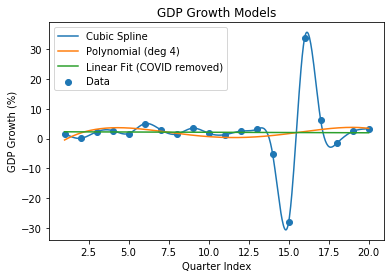

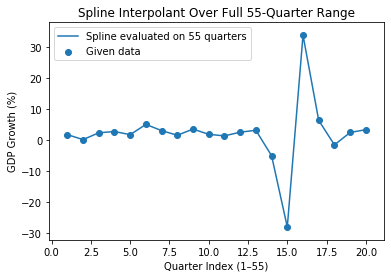

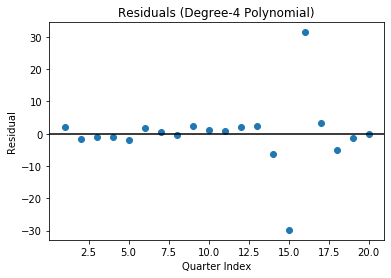

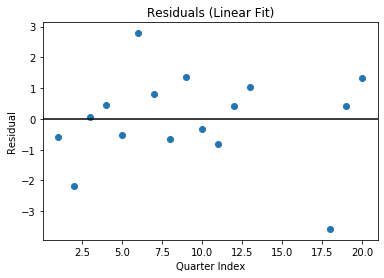

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Data

y = np.array([
    1.7, 0.1, 2.3, 2.7, 1.7,
    5.0, 3.0, 1.5, 3.5, 1.8,
    1.3, 2.5, 3.1, -5.1, -28.1,
    33.8, 6.3, -1.6, 2.4, 3.3])

# Subset x-values
x = np.arange(1, len(y) + 1)

# Full quarter index range
x_full = np.arange(1, 56)

# Cubic Spline

def natural_cubic_spline(x, y):
# Solves a tridiagonal system for second derivatives M.
    n = len(x)
    h = np.diff(x)

    A = np.zeros((n, n))
    rhs = np.zeros(n)

    # Natural boundary conditions
    A[0, 0] = 1
    A[-1, -1] = 1

    # Interior equations
    for i in range(1, n - 1):
        A[i, i - 1] = h[i - 1]
        A[i, i] = 2 * (h[i - 1] + h[i])
        A[i, i + 1] = h[i]
        rhs[i] = 6 * ((y[i + 1] - y[i]) / h[i] -
                      (y[i] - y[i - 1]) / h[i - 1])

    return np.linalg.solve(A, rhs)


def spline_eval(x, y, M, xq):
    """
    Evaluates the cubic spline at a query point xq.
    Returns NaN if xq is outside the spline domain.
    """
    if xq < x[0] or xq > x[-1]:
        return np.nan

    for i in range(len(x) - 1):
        if x[i] <= xq <= x[i + 1]:
            h = x[i + 1] - x[i]
            a = (x[i + 1] - xq) / h
            b = (xq - x[i]) / h
            return (a * y[i] + b * y[i + 1] +
                    ((a**3 - a) * M[i] + (b**3 - b) * M[i + 1]) * (h**2) / 6)


# Spline second derivatives
M = natural_cubic_spline(x, y)

# Evaluate spline on dense range
x_dense = np.linspace(1, len(y), 500)
y_spline = np.array([spline_eval(x, y, M, xi) for xi in x_dense])

# Evaluate spline at 55 quarter indices
y_spline_full = np.array([spline_eval(x, y, M, xi) for xi in x_full])


# Degree-4 Polynomial

def poly_fit(x, y, degree):
    V = np.vander(x, degree + 1)
    A = V.T @ V
    b_vec = V.T @ y
    return np.linalg.solve(A, b_vec)

def poly_eval(coeffs, x):
    return sum(c * x**i for i, c in enumerate(coeffs[::-1]))

coeffs = poly_fit(x, y, 4)
y_poly = np.array([poly_eval(coeffs, xi) for xi in x_dense])

# Polynomial residuals
y_poly_pred = np.array([poly_eval(coeffs, xi) for xi in x])
poly_residuals = y - y_poly_pred


# Linear Least Squares

covid_idx = np.array([13, 14, 15, 16])  # indices in the subset

mask = np.ones(len(x), dtype=bool)
mask[covid_idx] = False

x_lin = x[mask]
y_lin = y[mask]

A_lin = np.vstack([x_lin, np.ones(len(x_lin))]).T
ATA = A_lin.T @ A_lin
ATy = A_lin.T @ y_lin

m, b = np.linalg.solve(ATA, ATy)

print("Slope of linear model:", m)

y_line = m * x_dense + b
lin_residuals = y_lin - (m * x_lin + b)


# RMSE

def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted)**2))

rmse_poly = rmse(y, y_poly_pred)
rmse_lin = rmse(y_lin, m * x_lin + b)

spline_pred_subset = np.array([spline_eval(x, y, M, xi) for xi in x])
rmse_spline = rmse(y, spline_pred_subset)

print("RMSE (Spline):", rmse_spline)
print("RMSE (Degree-4 Polynomial):", rmse_poly)
print("RMSE (Linear, COVID removed):", rmse_lin)


# Plots

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_dense, y_spline, label="Cubic Spline")
plt.plot(x_dense, y_poly, label="Polynomial (deg 4)")
plt.plot(x_dense, y_line, label="Linear Fit (COVID removed)")
plt.title("GDP Growth Models")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.legend()

plt.figure()
plt.plot(x_full, y_spline_full, label="Spline evaluated on 55 quarters")
plt.scatter(x, y, label="Given data")
plt.title("Spline Interpolant Over Full 55-Quarter Range")
plt.xlabel("Quarter Index (1–55)")
plt.ylabel("GDP Growth (%)")
plt.legend()

plt.figure()
plt.scatter(x, poly_residuals)
plt.axhline(0, color='black')
plt.title("Residuals (Degree-4 Polynomial)")
plt.xlabel("Quarter Index")
plt.ylabel("Residual")

plt.figure()
plt.scatter(x_lin, lin_residuals)
plt.axhline(0, color='black')
plt.title("Residuals (Linear Fit)")
plt.xlabel("Quarter Index")
plt.ylabel("Residual")

plt.show()